# 10.4: Pipelines, Persistence, and Reproducible Inference

# 1. Pipelines

## 1.1 Conceptual Pipelines

Up to this point, we have been working with a conceptual supervised-learning pipeline. In earlier notebooks, each stage of the workflow, data curation, fingerprint generation, feature filtering, train/test splitting, model fitting, and evaluation, was executed explicitly and saved as intermediate artifacts. This approach emphasized transparency and pedagogy: students could see each transformation step, inspect the resulting files, and reason about how decisions made upstream influenced downstream model behavior. A key element of this workflow was the creation of a handoff artifact: a stable, non-volatile representation of molecular features that could be reused across modeling approaches.

In particular:

* **Notebook 10.1 (Data Preparation)** produced a curated molecular feature table
  (`data/AID743139/features/AID743139_MACCS_activities_noSalt_20260205.csv`)
  containing the *full MACCS fingerprint representation* for each compound, along with activity labels. This file represents the complete, unfiltered feature space and serves as a natural boundary between data preparation and modeling.

* **Notebook 10.2 (Model Construction)** began from this handoff artifact, converted the features into NumPy arrays, applied invariant-bit filtering *prior* to array generation, and created balanced training data for model fitting. At this stage, feature selection decisions were externalized and persisted as masks and metadata.

* **Notebook 10.3 (Model Evaluation)** examined the behavior of trained models using both class-based (`.predict`) and probability-based (`.predict_proba`) inference, operating on models trained from these precomputed arrays.

Together, these notebooks formed a **manual pipeline**: a reproducible sequence of steps in which intermediate representation (CSV files, `.npy` arrays, masks, and metadata) were saved and reloaded explicitly between notebooks.

---

## 1.2 Formal Pipelines

In Notebooks 10.1–10.3, we used scikit-learn in a *stepwise* manner: each transformation or modeling step was executed independently, with its inputs and outputs explicitly materialized as files or arrays. The handoff CSV created in Notebook 10.1 provided a stable starting point, but subsequent decisions—such as invariant-bit filtering and class balancing—were applied *outside* of scikit-learn and persisted as separate artifacts.

Scikit-learn provides an alternative way to organize the same operations: **formal pipeline objects**. In this approach, the same handoff artifact, the full MACCS fingerprint table generated in 10.1, serves as the conceptual starting point, but feature filtering and model fitting are no longer external preprocessing steps. Instead, they are incorporated directly into an ordered pipeline managed by scikit-learn.

A pipeline defines a sequence of steps, typically transformers followed by an estimator, and guarantees that these steps are applied consistently during both training and inference. Rather than manually coordinating feature preparation, filtering, and modeling across notebooks and saved files, the pipeline object becomes responsible for enforcing that logic.

Conceptually, nothing new is being introduced at the level of machine learning theory. The same classifiers, the same transformations, and the same evaluation methods are used. What changes is the software architecture, specifically, how these components are organized, connected, and persisted, which can be summarized as follows.

1. **Transformations are encapsulated, not externalized**
   Feature filtering and model fitting occur *inside* the pipeline. Intermediate arrays and masks are no longer saved as standalone artifacts; instead, they exist implicitly within the fitted pipeline object.

2. **The pipeline becomes the model**
   The trained pipeline—not individual `.npy` arrays or classifier objects—is what is persisted, shared, and reused. Saving a pipeline preserves both the learned model parameters and the preprocessing logic that produced them.

3. **Input representations may differ from earlier notebooks**
   Because invariant-bit filtering is now performed inside the pipeline, the effective feature representation used during training and inference may differ from the fixed 162-bit representation used in Notebook 10.2, even though both approaches begin from the same full MACCS fingerprint table.

4. **Reproducibility shifts from files to objects**
   Earlier notebooks emphasized non-volatile storage of intermediate data products to enable reconstruction. Formal pipelines instead emphasize object-level reproducibility: reloading a saved pipeline guarantees that future predictions apply the same ordered sequence of transformations learned during training.


# 2. Constructing and Training scikit-learn Pipeline
In this section, we construct a single scikit-learn pipeline architecture and train it under two different conditions:
1. Using a balanced training set (to reproduce the results of Notebook 10_2), and
2. Using the naturally imbalanced training set (to reflect real-world class prevalence).

Although the pipeline structure is identical in both cases, fitting it on different training data produces two distinct trained models. This allows us to separate architectural considerations (pipelines) from modeling decisions (class balancing).

We will first train the pipeline on the balanced training set to confirm that the pipeline reproduces the behavior observed in Notebook 10_2. We will then train the same pipeline architecture on the original imbalanced training data for comparison.

Later in the notebook, we will evaluate both trained pipelines and decide which version is appropriate to persist using joblib.

## 2.1 Load Feature table
We begin from the full MACCS fingerprint table created in Notebook 10.1. This CSV file represents the complete, unfiltered feature space and serves as the common starting point for both the manual and formal pipeline approaches.
From this artifact, we reconstruct the supervised learning inputs:

* X: a pandas DataFrame containing the MACCS fingerprint bits (feature matrix)
* y: a pandas Series containing the binary activity labels (target vector)

These objects define the feature space and classification labels that will be used for both training strategies (balanced and imbalanced).

In [1]:
# Reload full MACCS fingerprint dataset (from 10.1)

from pathlib import Path
import pandas as pd

data_path = Path(
    "data/AID743139/features/"
    "AID743139_MACCS_activities_noSalt_20260205.csv"
)

df = pd.read_csv(data_path)

# Separate features and labels
label_column = "activity"

maccs_columns = [col for col in df.columns if col.startswith("maccs")]

X = df[maccs_columns]      # keep as DataFrame
y = df[label_column]       # pandas Series

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)


Feature matrix shape: (6793, 167)
Label vector shape: (6793,)



## 2.2 Define Train/Test Split 
As in earlier notebooks, we define a reproducible train/test split before constructing or fitting the pipeline. The train/test partition is part of experimental design and is handled externally; scikit-learn’s `Pipeline` object applies transformations and modeling steps, but it does not define how data are partitioned for evaluation.

To ensure direct comparability with [Notebook 10_2](https://rebelford.github.io/2026Cheminformatics/content/modules/10_SupervisedML/10_2_NB_model_construction_workflow.html#train-test-split-a-9-1-ratio), we use the same split ratio (90/10), stratification strategy, and random seed (`random_state=3100`). This guarantees that the same observations appear in the training and test sets as in the earlier workflow.

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.1,
    random_state=3100,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)


Training shape: (6113, 167)
Test shape: (680, 167)


### 2.2.1 Converting to NumPy for Exact Reproduction of Notebook 10_2

Scikit-learn pipelines accept either pandas DataFrames or NumPy arrays as input. In this notebook, we will typically work with DataFrames because they preserve feature names and integrate naturally with pandas workflows.

However, in Notebook 10_2 the class-balancing step was implemented using NumPy index operations. To reproduce those results exactly, including the same downsampled observations and ordering, we temporarily convert the training and test sets to NumPy arrays before performing the balancing step.

This conversion is not required for pipeline construction in general; it is done here solely to ensure architectural equivalence with the earlier manual workflow.

### 2.2.2 Create Balanced Training Set
To reproduce the balanced-training workflow from Notebook 10_2, we downsample the majority class (inactive compounds) to match the number of minority-class observations (actives). The same random seed (0) and index-based NumPy selection are used to ensure identical training composition and ordering.

The resulting balanced training set contains equal numbers of active and inactive compounds and will be used to fit the first pipeline.

In [3]:
import numpy as np
import pandas as pd

# --- Convert y_train to NumPy ONLY for index selection (exact 10_2 behavior) ---
y_train_np = y_train.values

# Indices of each class
idx_inactives = np.where(y_train_np == 0)[0]
idx_actives   = np.where(y_train_np == 1)[0]

num_actives = len(idx_actives)

# SAME seed as 10_2
np.random.seed(0)

idx_inactives_downsampled = np.random.choice(
    idx_inactives,
    size=num_actives,
    replace=False
)

# --- Build balanced training set using Pandas (preserves feature names) ---
X_train_bal = pd.concat(
    [
        X_train.iloc[idx_inactives_downsampled],
        X_train.iloc[idx_actives]
    ],
    axis=0
)

y_train_bal = pd.concat(
    [
        y_train.iloc[idx_inactives_downsampled],
        y_train.iloc[idx_actives]
    ],
    axis=0
)

print("Balanced training shape:", X_train_bal.shape)

Balanced training shape: (1338, 167)


**Summary of Training Data Preparation**

At this stage, we have constructed two versions of the training data:

* Imbalanced training set (`X_train`, `y_train`), which reflects the natural class distribution of the dataset.
* Balanced training set (`X_train_bal`, `y_train_bal`), which was created using the same downsampling procedure and random seed as in Notebook 10_2.

Both training configurations share the same test set (`X_test`, `y_test`) to ensure consistent evaluation.

In the next section, we will define a single Naive Bayes pipeline architecture and fit it separately on each training set. Although the pipeline structure will be identical, fitting it on different training data will produce two distinct trained models for comparison.

## 2.3 Construct Pipeline
In Notebook 10_2, feature filtering and model fitting were performed as separate, manual steps. We first computed a variance mask to remove invariant MACCS bits and then fit a Bernoulli Naive Bayes classifier on the filtered feature matrix. As a result, the model in 10_2 was trained on a reduced fingerprint representation.

Here, we define a scikit-learn Pipeline that formalizes this same sequence of operations into a single object. The pipeline consists of two ordered steps:

  1. var_filter: a VarianceThreshold transformer with threshold=0.0, which removes invariant features (i.e., bits with zero variance).
  2. classifier: a BernoulliNB estimator that fits a Naive Bayes model to the filtered feature matrix.

Because the variance filtering step is now internal to the pipeline, we pass the full MACCS fingerprint matrix as input. The pipeline learns the appropriate feature mask from the training data and applies it automatically during both fitting and prediction. This reproduces the logic of Notebook 10_2 while encapsulating the preprocessing and modeling steps within a single, reusable object.

In [4]:
# Define a Naive Bayes pipeline that bundles preprocessing and classification

from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.naive_bayes import BernoulliNB

# Construct the pipeline
def make_nb_pipeline():
    return Pipeline(
        steps=[
            ("var_filter", VarianceThreshold(threshold=0.0)),
            ("classifier", BernoulliNB())
        ]
    )
nb_maccs_pipeline_bal = make_nb_pipeline()
nb_maccs_pipeline = make_nb_pipeline()


# Display the pipeline structure
nb_maccs_pipeline


,steps,"[('var_filter', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,threshold,0.0
,alpha,1.0
,force_alpha,True
,binarize,0.0
,fit_prior,True
,class_prior,None


When the final line of the cell evaluates nb_maccs_pipeline, Jupyter displays a structured summary of the pipeline object. This output shows the architecture of the workflow—its ordered steps and their configuration—without yet fitting the model to any data.

At this stage, nb_maccs_pipeline is an unfitted pipeline object. The summary includes:
* The ordered steps (var_filter and classifier)
* Constructor arguments for each component
* Default hyperparameters (e.g., alpha, fit_prior)
* Configuration values such as the variance threshold

Importantly, no feature mask has been learned and no classifier parameters have been estimated. The object defines the workflow structure, but it has not yet acquired state from data.



## 2.4 Fit the Pipeline
Fitting the pipeline trains both the preprocessing step and the classifier in a single coordinated operation. From this point forward, the fitted pipeline object contains all learned parameters required for inference.

In [5]:
# Train the Naive Bayes pipeline on the prepared MACCS fingerprints

nb_maccs_pipeline_bal.fit(X_train_bal, y_train_bal)
nb_maccs_pipeline.fit(X_train, y_train)


,steps,"[('var_filter', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,threshold,0.0
,alpha,1.0
,force_alpha,True
,binarize,0.0
,fit_prior,True
,class_prior,None


Note: The "state-aware object summary" has changed from brown/orange hues to blue hues and this indicates a change from before `.fit` to after `.fit` and the object is now trained  and the dropdown includes learned attributes in addtion to parameters.
  * learned attributes (e.g., variances, feature masks, class priors)
  * internal model state
  * dimensions inferred from the data

# 3. Inspecting and Evaluating the Fitted Pipeline
 .4.4 Verifying Consistency with Earlier Results

Before moving forward, it is good practice to confirm that introducing a pipeline has not changed the scientific outcome. At this stage, predictions made using the pipeline on the test set should match the predictions obtained earlier in [module 10_2 section 4.2](https://rebelford.github.io/2026Cheminformatics/content/modules/10_SupervisedML/10_2_NB_model_construction_workflow.html#load-feature-arrays-and-generate-the-confusion-matrix) using manual preprocessing and the standalone classifier.

This step serves two purposes:

* it builds trust in the pipeline abstraction,
* it reassures us that we have not altered the model, only its organization.



In [6]:
# Verify that the trained pipelines produce predictions on the same test set

from sklearn.metrics import confusion_matrix, accuracy_score

# Predictions
y_pred_bal   = nb_maccs_pipeline_bal.predict(X_test)
y_pred = nb_maccs_pipeline.predict(X_test)

# Confusion matrices
cm_bal   = confusion_matrix(y_test, y_pred_bal)
cm = confusion_matrix(y_test, y_pred)

# Accuracy
acc_bal   = accuracy_score(y_test, y_pred_bal)
acc = accuracy_score(y_test, y_pred)

print("Confusion Matrix (Balanced Training):")
print(cm_bal)

print("\nConfusion Matrix (Imbalanced Training):")
print(cm)

print(f"\nAccuracy (Balanced Training): {acc_bal:.3f}")
print(f"Accuracy (Imbalanced Training): {acc:.3f}")

Confusion Matrix (Balanced Training):
[[400 206]
 [ 25  49]]

Confusion Matrix (Imbalanced Training):
[[474 132]
 [ 34  40]]

Accuracy (Balanced Training): 0.660
Accuracy (Imbalanced Training): 0.756


In [7]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import numpy as np

# Predictions
y_pred_bal   = nb_maccs_pipeline_bal.predict(X_test)
y_pred = nb_maccs_pipeline.predict(X_test)

# Confusion matrices
cm_bal   = confusion_matrix(y_test, y_pred_bal)
cm = confusion_matrix(y_test, y_pred)

# Function to compute metrics from predictions
def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()
    
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    sens = recall_score(y_true, y_pred, zero_division=0)  # sensitivity (recall)
    spec = TN / (TN + FP) if (TN + FP) else 0.0
    bacc = (sens + spec) / 2
    f1   = f1_score(y_true, y_pred, zero_division=0)
    
    return acc, prec, sens, spec, bacc, f1

# Compute metrics
metrics_bal   = compute_metrics(y_test, y_pred_bal)
metrics = compute_metrics(y_test, y_pred)

# Create comparison table
metric_names = [
    "Accuracy",
    "Precision",
    "Sensitivity (Recall)",
    "Specificity",
    "Balanced Accuracy",
    "F1 Score"
]

comparison_df = pd.DataFrame({
    "Metric": metric_names,
    "Balanced Training": metrics_bal,
    "Imbalanced Training": metrics
})

comparison_df

,Metric,Balanced Training,Imbalanced Training
0,Accuracy,0.660294,0.755882
1,Precision,0.192157,0.232558
2,Sensitivity (Recall),0.662162,0.540541
3,Specificity,0.660066,0.782178
4,Balanced Accuracy,0.661114,0.661359
5,F1 Score,0.297872,0.325203


## 3.1 Interpretation of Balanced vs. Imbalanced Training

The two trained pipelines exhibit distinct performance profiles on the same test set. Although both models share identical architecture, the training distribution significantly influences their behavior.

### Overall Accuracy

The imbalanced-trained model achieves higher overall accuracy (0.756 vs. 0.660). This is expected because the dataset is dominated by inactive compounds; predicting the majority class more conservatively improves overall correctness. However, accuracy alone is misleading in imbalanced classification settings.

### Sensitivity vs. Specificity Tradeoff

Balanced training substantially increases sensitivity (recall) for the minority class:

* Balanced training: 0.662
* Imbalanced training: 0.541

This means the balanced-trained model identifies more active compounds.

In contrast, the imbalanced-trained model exhibits higher specificity:

* Balanced training: 0.660
* Imbalanced training: 0.782

Thus, the imbalanced-trained model is more conservative when predicting actives and produces fewer false positives.

This demonstrates the classical tradeoff:

* Balancing increases minority detection (higher recall).
* Natural training improves majority-class stability (higher specificity).

### Balanced Accuracy

Interestingly, the balanced accuracy is nearly identical for both models (~0.661). This indicates that when sensitivity and specificity are weighted equally, the two training strategies perform similarly overall. Balanced accuracy therefore reveals something accuracy alone hides: neither model is uniformly superior; they simply emphasize different error types.


### Precision and F1 Score

The imbalanced-trained model achieves slightly higher precision and F1 score. This reflects its more conservative prediction of actives, reducing false positives. Balanced training improves recall but at the cost of additional false positives, which lowers precision.

By encapsulating preprocessing and classification into a single object, we gain several advantages. Preprocessing steps are always applied consistently, feature selection decisions cannot be forgotten, input validation happens automatically and the trained workflow can be saved and reused. Most importantly, the pipeline now represents a reproducible scientific procedure. When we save it, reload it, or apply it to new molecules, we are re-executing the same operational assumptions under which the model was trained. In the next section, we will save this trained pipeline to disk and demonstrate how it can be reloaded after a kernel restart and applied to entirely new molecular datasets, without retraining.


# 4 Saving the Trained Pipeline with `joblib`
At this stage, we have two trained pipeline instances that share identical architecture but differ in their learned parameters due to differences in the training distribution.

* The balanced-trained pipeline emphasizes minority-class detection.
* The imbalanced-trained pipeline reflects the natural class prevalence of the dataset.

Because these pipelines encode different modeling assumptions, both are valid under different objectives. For instructional purposes, we will save both models to demonstrate that a fitted pipeline encapsulates not only preprocessing logic but also learned parameters and class priors. In applied settings, the choice of which model to deploy depends on the intended use case and the relative costs of false positives and false negatives.

## 4.1 joblib
When we run a Jupyter Notebook, all Python objects, dataframes, arrays, models, and pipelines, exist only in computer memory (RAM). This memory is volatile: if we restart the kernel, close the notebook, or shut down the computer, those objects disappear. To reuse a trained machine-learning model later, we need a way to store it on disk as a file and then reload it back into memory when needed. This is an example of moving information from volatile memory (RAM) to persistent storage (the file system).

Saving a model in this way is often called serialization: converting a complex Python object into a form that can be written to a file and later reconstructed. You can think of this as “freezing” a Python object so it can be stored and “thawed” later. Python provides multiple tools for doing this. In machine-learning workflows, we commonly use the joblib library because it is especially well suited for saving trained models and pipelines.

In particular, joblib:
  * efficiently stores objects that contain large NumPy arrays (such as fingerprints and model parameters),
  * works seamlessly with scikit-learn estimators and pipelines,
  * is widely used and recommended in the scikit-learn ecosystem.

For these reasons, we will use joblib to save our trained pipeline to disk and reload it later for reuse.

In [8]:
from pathlib import Path
import joblib
from cinf26pk.core import make_artifact_filename

# -------------------------------------------------
# Define model root
# -------------------------------------------------

MODEL_ROOT = Path("models/AID743139")
MODEL_ROOT.mkdir(parents=True, exist_ok=True)

# -------------------------------------------------
# Explicit model versions
# -------------------------------------------------

MODEL_VERSION = "v1"

fname_bal = make_artifact_filename(
    stem="nb_maccs_bal_AID743139",
    ext="joblib",
    version=MODEL_VERSION
)

fname_imbal = make_artifact_filename(
    stem="nb_maccs_natbal_AID743139",
    ext="joblib",
    version=MODEL_VERSION
)

# -------------------------------------------------
# Save models
# -------------------------------------------------

joblib.dump(nb_maccs_pipeline_bal, MODEL_ROOT / fname_bal)
joblib.dump(nb_maccs_pipeline, MODEL_ROOT / fname_imbal)

print(f"[Saved] Balanced model   → {MODEL_ROOT / fname_bal}")
print(f"[Saved] Imbalanced model → {MODEL_ROOT / fname_imbal}")


[Saved] Balanced model   → models/AID743139/nb_maccs_bal_AID743139_v1.joblib
[Saved] Imbalanced model → models/AID743139/nb_maccs_natbal_AID743139_v1.joblib


## 4.2 Reloading a Saved Pipeline
A trained scikit-learn pipeline can be restored from disk using joblib.load(). Reloading does not retrain the model; it restores the fully fitted pipeline exactly as it was at the time of saving, including all learned parameters and preprocessing steps. In this section, we reload both the balanced and naturally distributed training models so we can verify that their predictions remain unchanged after a kernel restart.

In [9]:
from pathlib import Path
import joblib

# Models directory
MODEL_DIR = Path("models/AID743139")

# Define model filenames
model_files = {
    "balanced": "nb_maccs_bal_AID743139_v1.joblib",
    "natural":  "nb_maccs_natbal_AID743139_v1.joblib"
}

# Load models into dictionary
loaded_models = {}

for label, filename in model_files.items():
    model_path = MODEL_DIR / filename
    loaded_models[label] = joblib.load(model_path)
    print(f"[Loaded] {label} model ← {model_path}")

# Access examples
nb_bal_loaded   = loaded_models["balanced"]
nb_nat_loaded   = loaded_models["natural"]


[Loaded] balanced model ← models/AID743139/nb_maccs_bal_AID743139_v1.joblib
[Loaded] natural model ← models/AID743139/nb_maccs_natbal_AID743139_v1.joblib


### 4.2.1 Reconstructing the Test Set
To verify that the reloaded pipelines produce identical results, we must recreate the exact same test set used during model evaluation. Because the original split was deterministic (random_state=3100 with stratification), re-running the split regenerates the identical hold-out data without retraining the models.

In [10]:
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split

# Reload feature table
data_path = Path(
    "data/AID743139/features/"
    "AID743139_MACCS_activities_noSalt_20260205.csv"
)

df = pd.read_csv(data_path)

# Recreate feature matrix and label vector
maccs_columns = [col for col in df.columns if col.startswith("maccs")]
X = df[maccs_columns]
y = df["activity"]

# Recreate exact same split
_, X_test, _, y_test = train_test_split(
    X, y,
    test_size=0.1,
    random_state=3100,
    stratify=y
)

### 4.2.2 Regenerating Confusion Matrices
With the reconstructed test set, we now generate predictions using the reloaded pipelines. The resulting confusion matrices and accuracy values should match those obtained before saving the models, confirming that serialization preserved all fitted parameters.

In [11]:
from sklearn.metrics import confusion_matrix, accuracy_score

# Generate predictions from reloaded models
y_pred_bal_loaded = nb_bal_loaded.predict(X_test)
y_pred_nat_loaded = nb_nat_loaded.predict(X_test)

# Compute confusion matrices
cm_bal_loaded = confusion_matrix(y_test, y_pred_bal_loaded)
cm_nat_loaded = confusion_matrix(y_test, y_pred_nat_loaded)


# Print results
print("Confusion Matrix (Balanced Model - Reloaded):")
print(cm_bal_loaded)

print("\nConfusion Matrix (Natural Distribution Model - Reloaded):")
print(cm_nat_loaded)

print("\nAccuracy (Balanced - Reloaded):",
      accuracy_score(y_test, y_pred_bal_loaded))

print("Accuracy (Natural - Reloaded):",
      accuracy_score(y_test, y_pred_nat_loaded))

Confusion Matrix (Balanced Model - Reloaded):
[[400 206]
 [ 25  49]]

Confusion Matrix (Natural Distribution Model - Reloaded):
[[474 132]
 [ 34  40]]

Accuracy (Balanced - Reloaded): 0.6602941176470588
Accuracy (Natural - Reloaded): 0.7558823529411764


Regenerate ROC curves and AUC score

### 4.2.3 Regenerating ROC Curve and AUC
Beyond discrete predictions, we evaluate the probabilistic outputs of each reloaded model. By computing ROC curves and AUC values on the reconstructed test set, we confirm that the probability estimates, and therefore threshold-independent performance, remain unchanged after reloading.

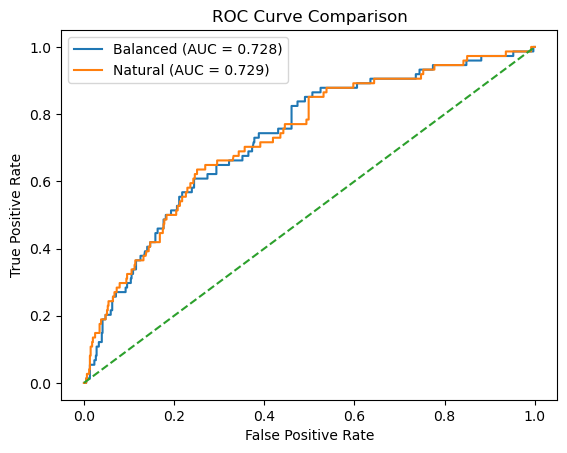

AUC (Balanced Training): 0.7279
AUC (Natural Training):  0.7287


In [12]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# -------------------------------------------------
# Predict probabilities for positive class (1 = active)
# -------------------------------------------------

y_proba_bal = nb_bal_loaded.predict_proba(X_test)[:, 1]
y_proba_nat = nb_nat_loaded.predict_proba(X_test)[:, 1]

# -------------------------------------------------
# Compute ROC curves
# -------------------------------------------------

fpr_bal, tpr_bal, _ = roc_curve(y_test, y_proba_bal)
fpr_nat, tpr_nat, _ = roc_curve(y_test, y_proba_nat)

# -------------------------------------------------
# Compute AUC
# -------------------------------------------------

auc_bal = roc_auc_score(y_test, y_proba_bal)
auc_nat = roc_auc_score(y_test, y_proba_nat)

# -------------------------------------------------
# Plot
# -------------------------------------------------

plt.figure()
plt.plot(fpr_bal, tpr_bal, label=f"Balanced (AUC = {auc_bal:.3f})")
plt.plot(fpr_nat, tpr_nat, label=f"Natural (AUC = {auc_nat:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")  # random baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

print(f"AUC (Balanced Training): {auc_bal:.4f}")
print(f"AUC (Natural Training):  {auc_nat:.4f}")

# 5 Using the Pipeline on New Molecules

Once a pipeline has been trained and saved, it can be reused to make predictions on molecules that were not part of the original dataset. This is the practical goal of building pipelines: applying the *same molecular representation and preprocessing* to new inputs and obtaining consistent predictions. At this stage, it is important to understand which steps must still be done manually and which steps are handled automatically by the pipeline.

## 5.1 What preprocessing is still required?

Our pipeline was trained on MACCS fingerprints, not on SMILES strings directly. This means we must still:
  * convert SMILES → RDKit molecule
  * generate the MACCS fingerprint
  * convert the fingerprint to a NumPy array

We do not need to:

  * apply the variance mask manually
  * align feature columns
  * worry about which bits were removed

Those steps are already encoded inside the pipeline.


## 5.2 Predicting activity for a single molecule

We begin with a single SMILES string.

The pipeline automatically:

* removes constant fingerprint bits,
* applies the same feature ordering used during training,
* and passes the transformed data to the classifier.

---

In [13]:
from rdkit import Chem
from rdkit.Chem import MACCSkeys
from rdkit.DataStructs import ConvertToNumpyArray
import numpy as np
import pandas as pd

# -------------------------------------------------
# Define query molecule
# -------------------------------------------------

new_smiles = "CC(=O)OC1=CC=CC=C1C(=O)O"  # Aspirin

mol = Chem.MolFromSmiles(new_smiles)
if mol is None:
    raise ValueError("Invalid SMILES string.")

# -------------------------------------------------
# Generate MACCS fingerprint
# -------------------------------------------------

fp = MACCSkeys.GenMACCSKeys(mol)

arr = np.zeros((fp.GetNumBits(),), dtype=int)
ConvertToNumpyArray(fp, arr)

# If training excluded bit 0, uncomment:
# arr = arr[1:]

#X_query = arr.reshape(1, -1)
# Get feature names from the trained pipeline
feature_names = nb_bal_loaded.named_steps["var_filter"].feature_names_in_

X_query = pd.DataFrame(
    arr.reshape(1, -1),
    columns=feature_names
)

# -------------------------------------------------
# Apply both models
# -------------------------------------------------

models = {
    "Balanced": nb_bal_loaded,
    "Natural":  nb_nat_loaded
}

results = []

for name, model in models.items():
    pred = model.predict(X_query)[0]
    proba = model.predict_proba(X_query)[0]
    
    results.append({
        "Model": name,
        "Predicted Class": pred,
        "P(Inactive)": proba[0],
        "P(Active)": proba[1]
    })

pd.DataFrame(results)

,Model,Predicted Class,P(Inactive),P(Active)
0,Balanced,0,0.782059,0.217941
1,Natural,0,0.971941,0.028059


## 5.3 Predicting Activity for a list of Molecules
In the next cell we will apply our trained Naïve Bayes pipelines to a list of new molecules represented as SMILES strings. For each molecule, the code will:
* Convert the SMILES string into an RDKit molecule object
* Generate a MACCS fingerprint
* Reconstruct a feature matrix row using the exact feature schema stored inside the trained pipeline
* Apply both the balanced and natural-distribution models
* Return predicted class labels and associated probabilities in a DataFrame
* Display the molecules rendered alongside their predictions

,SMILES,Molecule,Bal_Pred,Nat_Pred,Bal_P(Active),Nat_P(Active),Bal_P(Inactive),Nat_P(Inactive)
0,CC(=O)OC1=CC=CC=C1C(=O)O,,0,0,0.217941,0.028059,0.782059,0.971941
1,C1=CC=C(C=C1)C(C2=CC=CC=C2)(C3=CC=CC=C3Cl)N4C=...,,1,1,0.999318,0.991008,0.000682,0.008992
2,C1=CNC(=O)NC1=O,,1,0,0.551671,0.065252,0.448329,0.934748

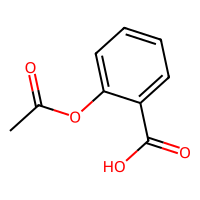
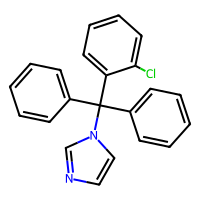
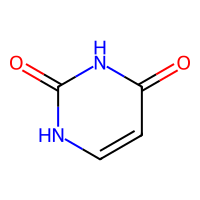

In [14]:
from rdkit import Chem
from rdkit.Chem import MACCSkeys
from rdkit.DataStructs import ConvertToNumpyArray
from rdkit.Chem import PandasTools
import numpy as np
import pandas as pd

# -------------------------------------------------
# Models must already be loaded:
# nb_bal_loaded
# nb_nat_loaded
# -------------------------------------------------

models = {
    "Bal": nb_bal_loaded,
    "Nat": nb_nat_loaded
}

# -------------------------------------------------
# Extract authoritative feature schema from pipeline
# -------------------------------------------------

feature_names = nb_bal_loaded.named_steps["var_filter"].feature_names_in_

# -------------------------------------------------
# Helper: SMILES → MACCS feature row (DataFrame)
# -------------------------------------------------

def smiles_to_query_df(smiles, feature_names):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None, None
    
    fp = MACCSkeys.GenMACCSKeys(mol)
    arr = np.zeros((fp.GetNumBits(),), dtype=int)
    ConvertToNumpyArray(fp, arr)
    
    X_query = pd.DataFrame(
        arr.reshape(1, -1),
        columns=feature_names
    )
    
    return mol, X_query

# -------------------------------------------------
# Input SMILES list
# -------------------------------------------------

smiles_list = [
    "CC(=O)OC1=CC=CC=C1C(=O)O",
    "C1=CC=C(C=C1)C(C2=CC=CC=C2)(C3=CC=CC=C3Cl)N4C=CN=C4",
    "C1=CNC(=O)NC1=O"
]

# -------------------------------------------------
# Build result table
# -------------------------------------------------

rows = []

for sm in smiles_list:
    mol, X_query = smiles_to_query_df(sm, feature_names)
    
    if mol is None:
        continue
    
    bal_pred = models["Bal"].predict(X_query)[0]
    nat_pred = models["Nat"].predict(X_query)[0]
    
    bal_proba = models["Bal"].predict_proba(X_query)[0]
    nat_proba = models["Nat"].predict_proba(X_query)[0]
    
    rows.append({
        "SMILES": sm,
        "Molecule": mol,
        "Bal_Pred": bal_pred,
        "Nat_Pred": nat_pred,
        "Bal_P(Active)": bal_proba[1],
        "Nat_P(Active)": nat_proba[1],
        "Bal_P(Inactive)": bal_proba[0],
        "Nat_P(Inactive)": nat_proba[0],
    })

df_results = pd.DataFrame(rows)

# Explicit column order
df_results = df_results[
    [
        "SMILES",
        "Molecule",
        "Bal_Pred",
        "Nat_Pred",
        "Bal_P(Active)",
        "Nat_P(Active)",
        "Bal_P(Inactive)",
        "Nat_P(Inactive)"
    ]
]

# Enable RDKit rendering
PandasTools.RenderImagesInAllDataFrames(images=True)

df_results

**Adding Names using PubChem requests API:** the following cell adds a column with the molecules name.  This cell will take a while to run if your list is too long.

,Name,Molecule,Bal_Pred,Nat_Pred,Bal_P(Active),Nat_P(Active),Bal_P(Inactive),Nat_P(Inactive),SMILES
0,Aspirin,,0,0,0.217941,0.028059,0.782059,0.971941,CC(=O)OC1=CC=CC=C1C(=O)O
1,Clotrimazole,,1,1,0.999318,0.991008,0.000682,0.008992,C1=CC=C(C=C1)C(C2=CC=CC=C2)(C3=CC=CC=C3Cl)N4C=...
2,Uracil,,1,0,0.551671,0.065252,0.448329,0.934748,C1=CNC(=O)NC1=O

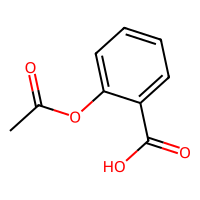
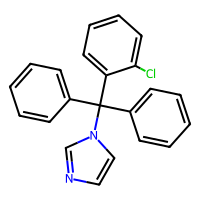
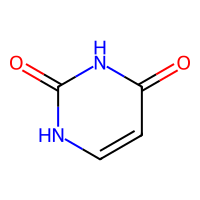

In [15]:
from rdkit import Chem
from rdkit.Chem import MACCSkeys
from rdkit.DataStructs import ConvertToNumpyArray
from rdkit.Chem import PandasTools
import numpy as np
import pandas as pd
import requests
import time

# -------------------------------------------------
# Models must already be loaded:
# nb_bal_loaded
# nb_nat_loaded
# -------------------------------------------------

models = {
    "Bal": nb_bal_loaded,
    "Nat": nb_nat_loaded
}

# -------------------------------------------------
# Extract authoritative feature schema from model
# -------------------------------------------------

feature_names = nb_bal_loaded.named_steps["var_filter"].feature_names_in_

# -------------------------------------------------
# Persistent HTTP session for PubChem
# -------------------------------------------------

session = requests.Session()

def smiles_to_pubchem_name(smiles):
    """
    Query PubChem for compound name (Title) from SMILES.
    Single request for efficiency.
    """
    try:
        url = (
            "https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/smiles/"
            f"{smiles}/property/Title/JSON"
        )
        r = session.get(url, timeout=20)
        r.raise_for_status()
        return r.json()["PropertyTable"]["Properties"][0]["Title"]
    except Exception:
        return "Unknown"

# -------------------------------------------------
# Helper: SMILES → MACCS feature row (DataFrame)
# -------------------------------------------------

def smiles_to_query_df(smiles, feature_names):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None, None
    
    fp = MACCSkeys.GenMACCSKeys(mol)
    arr = np.zeros((fp.GetNumBits(),), dtype=int)
    ConvertToNumpyArray(fp, arr)
    
    X_query = pd.DataFrame(
        arr.reshape(1, -1),
        columns=feature_names
    )
    
    return mol, X_query

# -------------------------------------------------
# Input SMILES list
# -------------------------------------------------

smiles_list = [
    "CC(=O)OC1=CC=CC=C1C(=O)O",  # aspirin
    "C1=CC=C(C=C1)C(C2=CC=CC=C2)(C3=CC=CC=C3Cl)N4C=CN=C4",
    "C1=CNC(=O)NC1=O"
]

# -------------------------------------------------
# Build result table
# -------------------------------------------------

rows = []

for sm in smiles_list:
    name = smiles_to_pubchem_name(sm)
    mol, X_query = smiles_to_query_df(sm, feature_names)
    
    if mol is None:
        continue
    
    mol.SetProp("_Name", name)
    
    bal_pred = models["Bal"].predict(X_query)[0]
    nat_pred = models["Nat"].predict(X_query)[0]
    
    bal_proba = models["Bal"].predict_proba(X_query)[0]
    nat_proba = models["Nat"].predict_proba(X_query)[0]
    
    rows.append({
        "Name": name,
        "Molecule": mol,
        "Bal_Pred": bal_pred,
        "Nat_Pred": nat_pred,
        "Bal_P(Active)": bal_proba[1],
        "Nat_P(Active)": nat_proba[1],
        "Bal_P(Inactive)": bal_proba[0],
        "Nat_P(Inactive)": nat_proba[0],
        "SMILES": sm
    })
    
    time.sleep(0.2)  # polite pause

df_results = pd.DataFrame(rows)

# Reorder columns explicitly (as requested)
df_results = df_results[
    [
        "Name",
        "Molecule",
        "Bal_Pred",
        "Nat_Pred",
        "Bal_P(Active)",
        "Nat_P(Active)",
        "Bal_P(Inactive)",
        "Nat_P(Inactive)",
        "SMILES"
    ]
]

# Enable RDKit rendering
PandasTools.RenderImagesInAllDataFrames(images=True)

df_results

# Homework
## Problem 1: hw_10.4_Pipelines
Using the csv file you created in Problem 2:hw_10.1_data_prep.ipynb repeat the procedures of this module for your AID

## Problem 2: hw_10.4_Pipelines
Find a list of 20 SMILES and run them through your pipeline to predict activity as was done in section 5.3 of this module

# Acknowledgements
cc 4.0 by Robert Belford, this work is built on prior work by Sunghwan Kim for the 2019 Cheminformatics OLCC [section 8.3: Machine Learning Basics](https://chem.libretexts.org/Courses/Intercollegiate_Courses/Cheminformatics/08%3A_Machine-learning_Basics/8.03%3A_Python_Assignment) and Ehren Bulcholtz for the [Fall 2025 Chem3351 class at UHSP](https://github.com/ebucholtz/CHEM3351)